In [50]:
import numpy as np 
import pandas as pd

In [51]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [52]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4696,ham,"Okey dokey, iÛ÷ll be over in a bit just sorti...",NaN,NaN,NaN
3083,ham,Ok lor. I ned 2 go toa payoh 4 a while 2 retur...,NaN,NaN,NaN
790,ham,This is hoping you enjoyed your game yesterday...,NaN,NaN,NaN
42,spam,07732584351 - Rodger Burns - MSG = We tried to...,NaN,NaN,NaN
1208,ham,Also maaaan are you missing out,NaN,NaN,NaN


In [53]:
#steps:
#1. Data Cleaning
#2. EDA
#3. Text Preprocessing
#4. Model Building
#5. Evaluation
#6. Improvement
#7. Website 
#8. Deployment

### 1. Data cleaning

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [55]:
# drop last 3  unnamed columns
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True) #including space is very important after this ':'

In [56]:
df.sample(5)

,v1,v2
1308,ham,I jokin oni lar.. ÌÏ busy then i wun disturb Ì_.
584,ham,So how's scotland. Hope you are not over showi...
2668,spam,Wanna get laid 2nite? Want real Dogging locati...
2730,ham,I havent lei.. Next mon can?
997,ham,Not a lot has happened here. Feels very quiet....


In [57]:
# rename columns name v1: target, v2: text
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)

In [58]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [59]:
# convert target column into numerical values
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [60]:
df['target'] = encoder.fit_transform(df['target'])
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [61]:
#missing values check
df.isnull().sum()

target    0
text      0
dtype: int64

In [62]:
#check for duplicate values
df.duplicated().sum()

403

In [63]:
# remove duplicate values
df=df.drop_duplicates(keep='first')

In [64]:
df.duplicated().sum();

In [65]:
df.shape

(5169, 2)

### 2.EDA

In [66]:
#count spam and ham messages
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x2d797c92610>,
 [Text(-1.0144997251399075, 0.4251944351600247, 'ham'),
  Text(1.014499764949479, -0.4251943401757036, 'spam')],
 [Text(-0.5533634864399495, 0.23192423736001344, '87.37'),
  Text(0.5533635081542612, -0.23192418555038377, '12.63')])

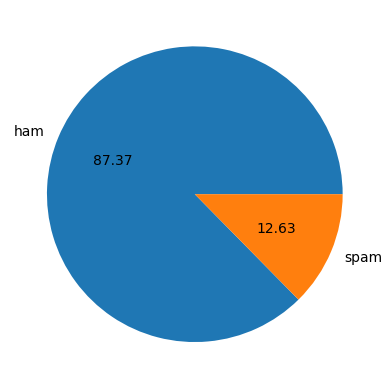

In [67]:
# use matplotlib for visualization
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")

In [68]:
# above data is imbalanced data
# use nltk library for text preprocessing
%pip install nltk
import nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SiddhantPatel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SiddhantPatel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [70]:
# new feature creation: num_characters , it is used to count number of characters in each message
df.loc[:, 'num_characters'] = df['text'].str.len()

C:\Users\SiddhantPatel\AppData\Local\Temp\ipykernel_6668\4117934713.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'num_characters'] = df['text'].str.len()


In [71]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [72]:
# num of words (tokens) in each message for processing
df.loc[:,'num_words']=df["text"].apply(lambda x:len( nltk.word_tokenize(x)))

C:\Users\SiddhantPatel\AppData\Local\Temp\ipykernel_6668\3384776932.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'num_words']=df["text"].apply(lambda x:len( nltk.word_tokenize(x)))


In [73]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [74]:
# num of sentences in each message for processing
df.loc[:,'num_sentences']=df["text"].apply(lambda x:len( nltk.sent_tokenize(x)))


C:\Users\SiddhantPatel\AppData\Local\Temp\ipykernel_6668\2883601623.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'num_sentences']=df["text"].apply(lambda x:len( nltk.sent_tokenize(x)))


In [75]:
# exploratory data analysis
df[['num_characters','num_words']].describe()

,num_characters,num_words
count,5169.000000,5169.000000
mean,78.977945,18.455794
std,58.236293,13.324758
min,2.000000,1.000000
25%,36.000000,9.000000
50%,60.000000,15.000000
75%,117.000000,26.000000
max,910.000000,220.000000


In [76]:
# ham messages 
df[df['target']==0][['num_characters','num_words','num_sentences']].describe() 

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [77]:
# spam messages
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_words', ylabel='Count'>

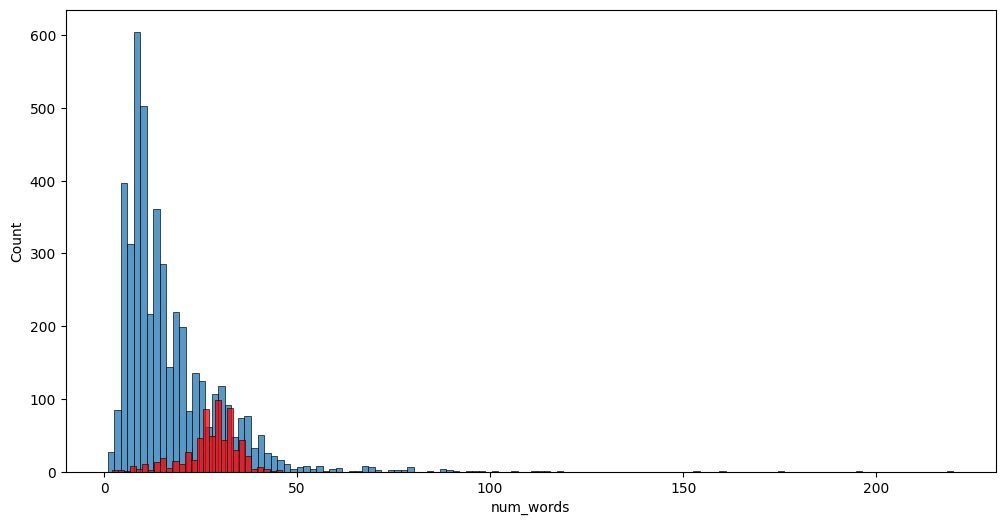

In [78]:
# plot a histogram for spam and ham messages
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')


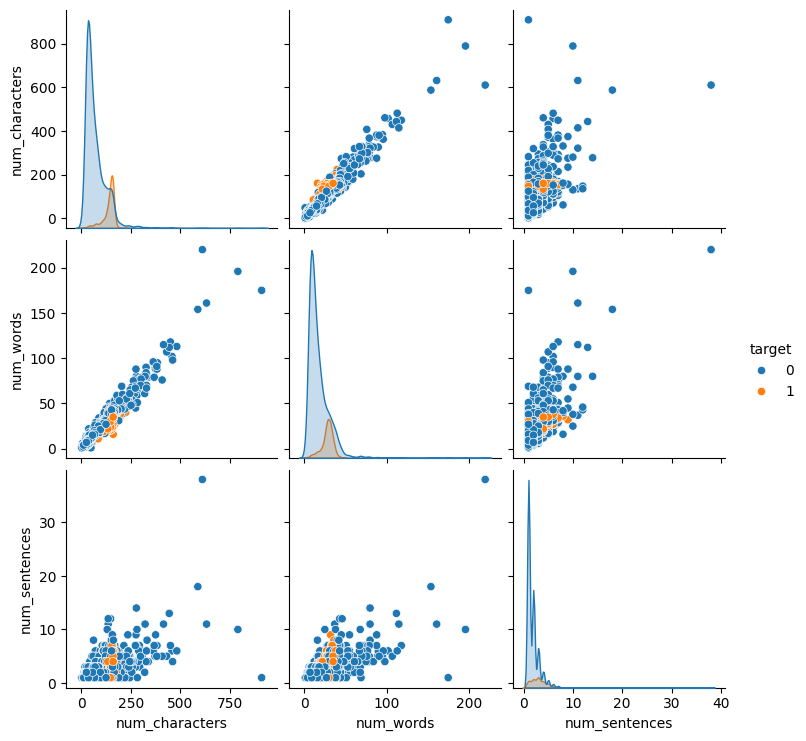

In [79]:
sns.pairplot(df,hue='target')

In [80]:
df.dtypes

target             int32
text              object
num_characters     int64
num_words          int64
num_sentences      int64
dtype: object

<Axes: >

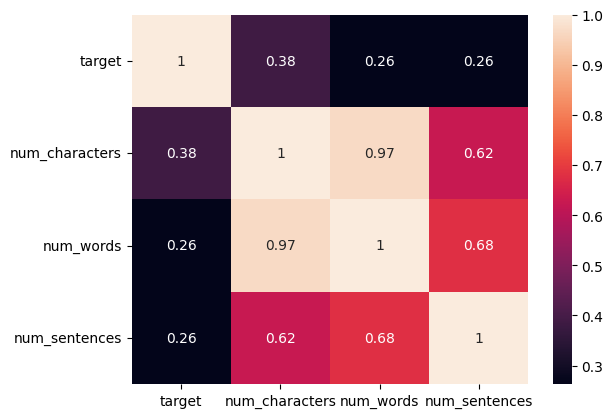

In [81]:
# select only numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True)


### 3.DAta preprocessing
#### . convert in lower case
#### . tokenization
#### . remove special characters
#### . removing full stops and punctuation
#### . stemming


In [83]:
# remove puctuation marks
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# remove stop words and punctuation
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')


In [89]:
def tranform_text(text):
    text = text.lower()  # convert text to lowercase
    text = nltk.word_tokenize(text)  # tokenize the text

    y = []
    for i in text:
        if i.isalnum():  # check if the token is alphanumeeric
            y.append(i)

    text = y[:] # copy the list y to text
    y.clear()  # clear the list y to free up memory

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    return y

In [91]:
tranform_text("Hello World!  This is a test message. my  siddhant")

['hello', 'world', 'test', 'message', 'siddhant']

In [92]:
#last step : stemming
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
def tranform_text(text):
    text = text.lower()  # convert text to lowercase
    text = nltk.word_tokenize(text)  # tokenize the text

    y = []
    for i in text:
        if i.isalnum():  # check if the token is alphanumeeric
            y.append(i)

    text = y[:] # copy the list y to text
    y.clear()  # clear the list y to free up memory

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text = y[:] # copy the list y to text
    y.clear()  # clear the list y to free up memory

    for i in text:
        y.append(ps.stem(i))  # stemming of each word

    return y

In [104]:
tranform_text("Hello World!. hi, us ,i shall This is a test message. it learning it my will  siddhant. it's me")

['hello', 'world', 'hi', 'us', 'shall', 'test', 'messag', 'learn', 'siddhant']

In [109]:
tranform_text(df['text'][10])

['gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today']

In [110]:
# apply the tranform_text function to the text column of the dataframe
df['transformed_text'] = df['text'].apply(tranform_text)

C:\Users\SiddhantPatel\AppData\Local\Temp\ipykernel_6668\2451821522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text'] = df['text'].apply(tranform_text)


In [111]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


In [162]:
# word cloud for ham messages
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [163]:
spam_text = df[df['target'] == 1]['transformed_text'].astype(str).str.cat(sep=" ")
spam_wc = wc.generate(spam_text)


In [164]:
type(spam_wc)

wordcloud.wordcloud.WordCloud

In [165]:
print(type(spam_wc))


<class 'wordcloud.wordcloud.WordCloud'>


In [ ]:
plt.imshow(spam_wc.to_array())
plt.axis("off")
plt.show()


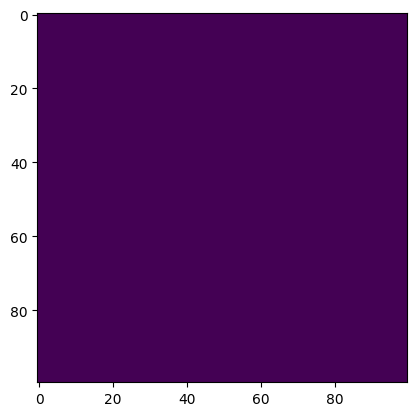

In [166]:
import numpy as np
test = np.zeros((100, 100))
plt.imshow(test)
plt.show()


In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [168]:
import matplotlib
print(matplotlib.__version__)



3.8.4


In [169]:
pip install --upgrade matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/6f/d3/a4bbc01c237ab710a1f22b4da72f4ff6d77eb4c7735ea9811a94ae239067/matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.8.4
    Uninstalling matplotlib-3.8.4:
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\siddhantpatel\\appdata\\local\\programs\\python\\python311\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [170]:
import matplotlib
print(matplotlib.__version__)


3.8.4


In [171]:
plt.figure(figsize=(6,6))
plt.imshow(spam_wc.to_array())
plt.axis("off")
plt.show()


TypeError: asarray() got an unexpected keyword argument 'copy'

<Figure size 600x600 with 0 Axes>

In [ ]:
pip uninstall matplotlib numpy -y,
pip install numpy==1.26.4,
pip install matplotlib==3.8.4


SyntaxError: invalid syntax (3590206703.py, line 1)